## Deep Learning

In this project, we'll look at a data science competition helping scientists track animals in a wildlife preserve. The goal is to take images from camera traps and classify which animal, if any, is present. To complete the competition, you'll expand your machine learning skills by creating more powerful neural network models that can take images as inputs and classify them into one of multiple categories.

**Some of the things you'll learn are:**
- How to read image files and prepare them for machine learning
- How to use PyTorch to manipulate tensors and build a neural network model
- How to build a Convolutional Neural Network that works well with images
- How to use that model to make predictions on new images
- How to turn those predictions into a submission to the competition

Before we can start this lesson there are two things we need to do. First, we need to import the libraries that we'll need to get our work done.

In [60]:
import os
import sys

import matplotlib
import matplotlib.pyplot as plt
import pandas as pd

import PIL
import torch
import torchvision

from PIL import Image
from torchvision import transforms

It's a good idea to print out the version numbers for your libraries, including Python. That way, anyone who reviews your work will know exactly what software is used in case they want to reproduce it.

In [61]:
# if you don't have it installed, use the command below

# %pip install torch torchvision torchaudio

In [62]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("matplotlib version:", matplotlib.__version__)
print("pandas version:", pd.__version__)
print("PIL version:", PIL.__version__)
print("torch version:", torch.__version__)
print("torchvision version:", torchvision.__version__)

Platform: linux
Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
---
matplotlib version: 3.10.0
pandas version: 2.2.2
PIL version: 11.3.0
torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128


### Objectives:

- Check important attributes of tensors, such as size, data type, and device.
- Manipulate tensors through slicing.
- Perform mathematical operations with tensors, including matrix multiplication and aggregation calculations.
- Download and decompress the dataset for this project.
- Load and explore images using PIL.
- Demonstrate how visual information is stored in tensors, focusing on color channels.

New Terms: **Attribute, Class, Color channel, Method, Tensor**

### Summary:
In summary, we'll learn how to work with tensors in PyTorch. We'll also explore the dataset for this project, focusing on how images are represented in tensors.

### Working with Tensors in PyTorch

### What are Tensors?
The term **tensor** comes from mathematics. It refers to an array of values organized into one or more dimensions. In Pytorch it's built for **deep learning**. 

In Python, there are several libraries for creating and manipulating tensors. In this example, we'll use PyTorch, which is built for **deep learning**. We'll build our computer visions with PyTorch.

In this section, we'll get familiar with **tensors** and what we can do with them. We'll begin making a 2-dimensional tensor from a nested list.

In [65]:
# Check if GPUs available via `cuda`
print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU Name: Tesla T4


From the output above, I now have a Tesla T4 GPU. I'm now running on `NVIDIA Tesla T4`

Key characteristics:

- 16GB GDDR6 VRAM
- Optimized for deep learning inference/training
- Common in Colab Pro / free-tier GPUs
- CUDA-compatible (PyTorch works natively)

To properly use the GPU, we have to move our model to our GPU.

In [66]:
#Getting the cuda device
device = torch.device("cuda")
#Move `my_tensor` to device
my_tensor = my_tensor.to(device)

print("my_tensor device:", my_tensor.device)

my_tensor device: cuda:0


## Explore Files

In this section, we'll focus on the `multi-class training data`. Let's define a variable for the directory that includes all the `multi-class data` and one for that contains the `training data`.

In [76]:
from google.colab import drive

# Mount Drive in Colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [77]:
features = pd.read_csv("/content/drive/MyDrive/image_classification_datasets/train_features.csv")
labels = pd.read_csv("/content/drive/MyDrive/image_classification_datasets/train_labels.csv")

In [78]:
# Merge them
df = features.merge(labels, on="id")
print(df.columns)

Index(['id', 'filepath', 'site', 'antelope_duiker', 'bird', 'blank',
       'civet_genet', 'hog', 'leopard', 'monkey_prosimian', 'rodent'],
      dtype='object')


In [79]:
# Convert one-hot → single label
df['label'] = df.iloc[:, 3:].idxmax(axis=1) #selects all class columns and returns column name with value = 1

# Inspect classes
print(df['label'].unique())

['bird' 'monkey_prosimian' 'leopard' 'hog' 'civet_genet' 'antelope_duiker'
 'blank' 'rodent']


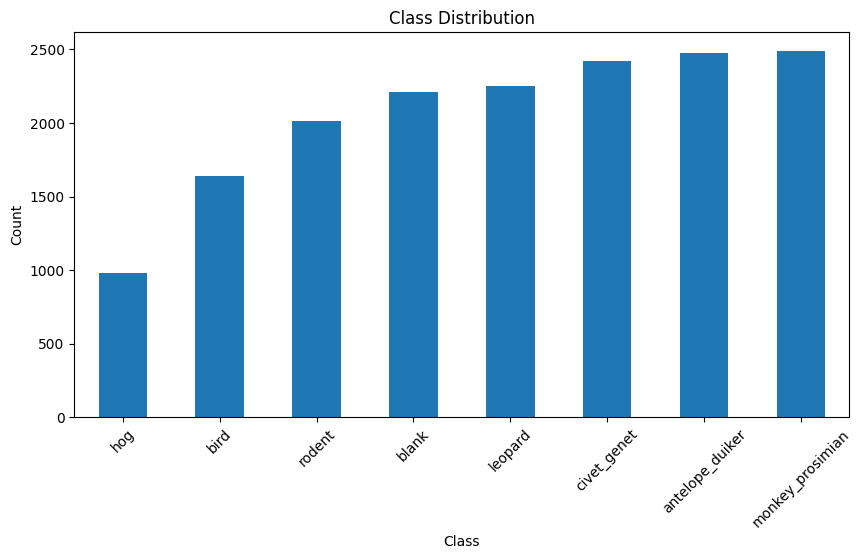

In [80]:
# Let's plot the visualization
class_counts = df['label'].value_counts().sort_values()

class_counts.plot(kind='bar', figsize=(10,5))

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

**Load Images**

Let's create the path and store it inside the `dataset_path` variable

In [81]:
# Access dataset path
dataset_path = "/content/drive/MyDrive/image_classification_datasets/train_features"

# loading images
print(os.listdir(dataset_path))

['ZJ004033.jpg', 'ZJ006632.jpg', 'ZJ014220.jpg', 'ZJ016437.jpg', 'ZJ003992.jpg', 'ZJ009271.jpg', 'ZJ016351.jpg', 'ZJ002442.jpg', 'ZJ013559.jpg', 'ZJ006630.jpg', 'ZJ002332.jpg', 'ZJ000533.jpg', 'ZJ016421.jpg', 'ZJ006624.jpg', 'ZJ015658.jpg', 'ZJ006142.jpg', 'ZJ009503.jpg', 'ZJ014546.jpg', 'ZJ012137.jpg', 'ZJ000243.jpg', 'ZJ009501.jpg', 'ZJ000241.jpg', 'ZJ008635.jpg', 'ZJ016345.jpg', 'ZJ015116.jpg', 'ZJ007260.jpg', 'ZJ005339.jpg', 'ZJ010734.jpg', 'ZJ002318.jpg', 'ZJ003760.jpg', 'ZJ002456.jpg', 'ZJ015102.jpg', 'ZJ015664.jpg', 'ZJ003006.jpg', 'ZJ001639.jpg', 'ZJ012645.jpg', 'ZJ005477.jpg', 'ZJ003990.jpg', 'ZJ003748.jpg', 'ZJ011364.jpg', 'ZJ005305.jpg', 'ZJ004999.jpg', 'ZJ007248.jpg', 'ZJ008153.jpg', 'ZJ012679.jpg', 'ZJ011402.jpg', 'ZJ015894.jpg', 'ZJ004027.jpg', 'ZJ000527.jpg', 'ZJ013573.jpg', 'ZJ001611.jpg', 'ZJ014552.jpg', 'ZJ003774.jpg', 'ZJ014234.jpg', 'ZJ014208.jpg', 'ZJ004741.jpg', 'ZJ009265.jpg', 'ZJ005311.jpg', 'ZJ004769.jpg', 'ZJ002330.jpg', 'ZJ000269.jpg', 'ZJ013567.jpg', 'ZJ0011

Let's pick two images from our train datasets and view it.

In [82]:
# hog image
hog_row = df[df['label'] == 'hog'].iloc[0]
hog_image_path = "/content/drive/MyDrive/image_classification_datasets/" + hog_row['filepath']

# antelope image
antelope_row = df[df['label'] == 'antelope_duiker'].iloc[0]
antelope_image_path = "/content/drive/MyDrive/image_classification_datasets/" + antelope_row['filepath']

print(hog_image_path)
print(antelope_image_path)

/content/drive/MyDrive/image_classification_datasets/train_features/ZJ000005.jpg
/content/drive/MyDrive/image_classification_datasets/train_features/ZJ000007.jpg


*To load these images, we'll use the [Pillow library](https://pillow.readthedocs.io/en/stable/index.html) (aka PIL), which comes with lots of tools for image processing. We'll start with the hog.*

hog_image_pil type: <class 'PIL.JpegImagePlugin.JpegImageFile'>


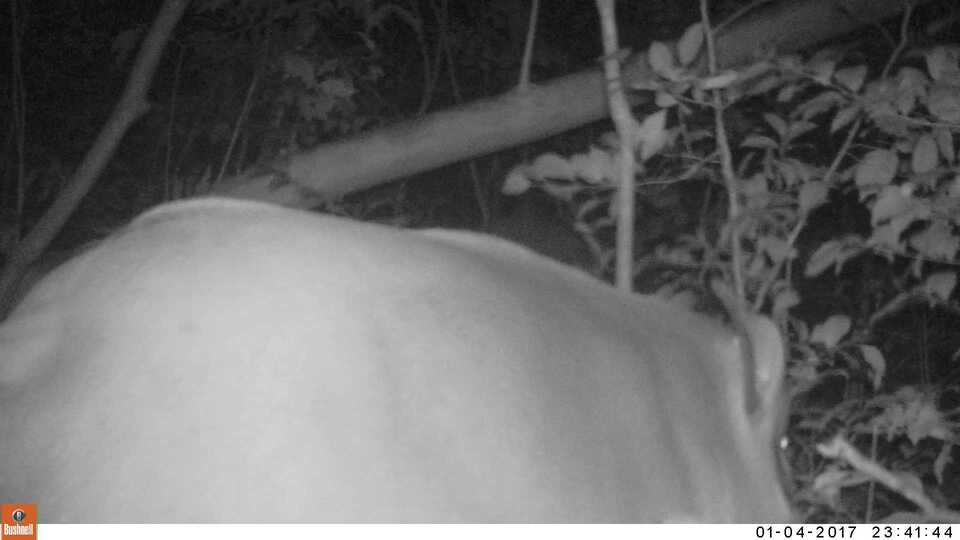

In [83]:
# Use PIL to open `hog_image_pil` and `antelope_image_path.`
# `hog_image_pil`
hog_image_pil = Image.open(hog_image_path)

print("hog_image_pil type:", type(hog_image_pil))
hog_image_pil


blank_image_ type: <class 'PIL.JpegImagePlugin.JpegImageFile'>


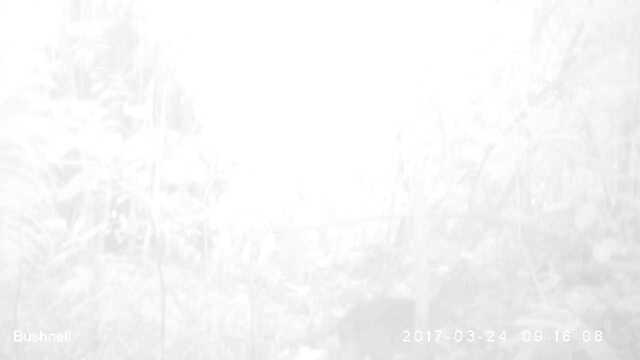

In [84]:
# `antelope_image_path`.
antelope_image_pil = Image.open(antelope_image_path)

print("blank_image_ type:", type(antelope_image_pil))
antelope_image_pil

/content/drive/MyDrive/image_classification_datasets/train_features/ZJ002533.jpg
True


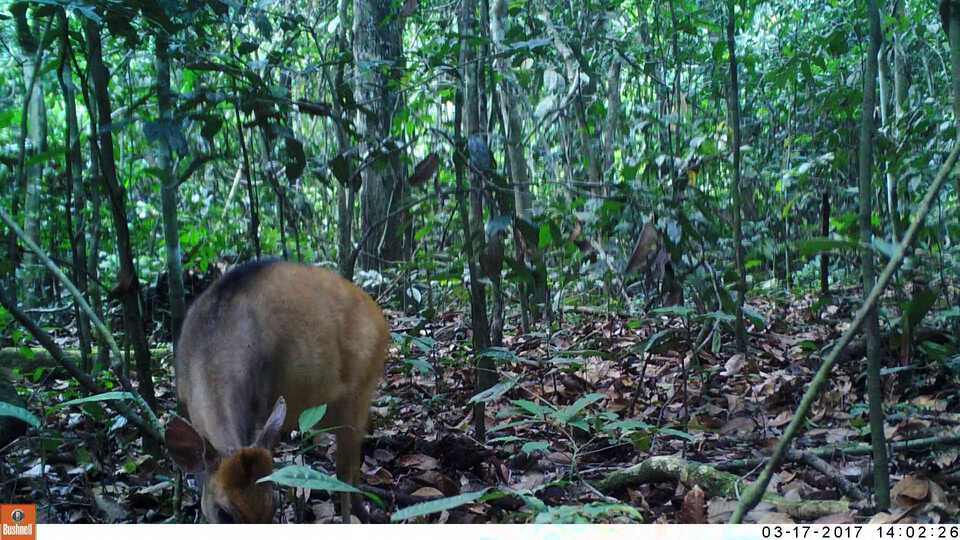

In [85]:
# Let's load another `antelope_image_path` to display a colored image
antelope_colored_image_path = os.path.join(dataset_path, "ZJ002533.jpg")

print(antelope_colored_image_path)
print(os.path.exists(antelope_colored_image_path))  # should be True

antelope_image_color = Image.open(antelope_colored_image_path)
antelope_image_color

/content/drive/MyDrive/image_classification_datasets/train_features/ZJ000072.jpg
True


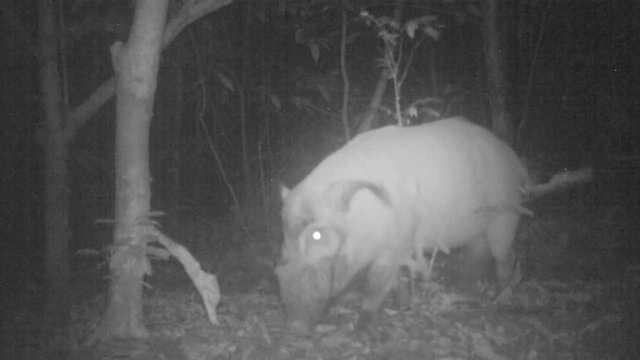

In [86]:
# Let's load another `hog_image` to display a non colored image
hog_not_colored_image_path = os.path.join(dataset_path, "ZJ000072.jpg")

print(hog_not_colored_image_path)
print(os.path.exists(hog_not_colored_image_path))  # should be True

hog_image_not_color = Image.open(hog_not_colored_image_path)
hog_image_not_color

Do you see any differences in the way these images above look? Let's keep using `PIL` to explore further, looking at their `.size` and `.mode` attributes. Again, we'll start with the `hog` and then do the `antelope`.

In [87]:
# Get image size
hog_image_pil_size = hog_image_not_color.size

# Get image mode
hog_image_pil_mode = hog_image_not_color.mode

# Print results
print("hog_image_pil_size class:", type(hog_image_pil_size))
print("hog_image_pil_size length:", len(hog_image_pil_size))
print("Hog image size:", hog_image_pil_size)
print()
print("hog_image_pil_mode class:", type(hog_image_pil_mode))
print("Hog image mode:", hog_image_pil_mode)

hog_image_pil_size class: <class 'tuple'>
hog_image_pil_size length: 2
Hog image size: (640, 360)

hog_image_pil_mode class: <class 'str'>
Hog image mode: L


In [88]:
# Get image size
antelope_image_pil_size = antelope_image_color.size

# Get image mode
antelope_image_pil_mode = antelope_image_color.mode

# Get image mode
print("antelope_image_pil_size class:", type(antelope_image_pil_size))
print("antelope_image_pil_size length:", len(antelope_image_pil_size))
print("Antelope image size:", antelope_image_pil_size)
print()
print("antelope_image_pil_mode class:", type(antelope_image_pil_mode))
print("Antelope image mode:", antelope_image_pil_mode)

antelope_image_pil_size class: <class 'tuple'>
antelope_image_pil_size length: 2
Antelope image size: (960, 540)

antelope_image_pil_mode class: <class 'str'>
Antelope image mode: RGB


Looking at these attributes, we can confirm that there are two differences between our images.

- **Mode:** The hog image is in grayscale (`mode="L"`), while the antelope image is in color mode (`mode="RGB"`).
- **Size:** The hog images is smaller than the antelope image.

These differences are important because all the images in our dataset must have the same size and mode before we can use them to train a model.

**Load Tensors**

We've loaded two image files using the Pillow library. For that reason, they're represented using the JpegImageFile() class. However, we'll need to represent them as tensors if we want to train a model.

The PyTorch community has created the torchvision library, which comes with lots of helpful transformation tools. We can use the ToTensor() class to convert hog_image_pil to a tensor.

In [89]:
hog_tensor = transforms.ToTensor()(hog_image_not_color)

print("hog_tensor type:", type(hog_tensor))
print("hog_tensor shape:", hog_tensor.shape)
print("hog_tensor dtype:", hog_tensor.dtype)
print("hog_tensor device:", hog_tensor.device)

hog_tensor type: <class 'torch.Tensor'>
hog_tensor shape: torch.Size([1, 360, 640])
hog_tensor dtype: torch.float32
hog_tensor device: cpu


Take a moment to examine the `syntax` we used to convert the hog image into a `tensor`.🔍 `ToTensor()` is a class. (You can check out the class definition [here](https://docs.pytorch.org/vision/main/_modules/torchvision/transforms/transforms.html#ToTensor).) However, we're using it like a function, combining it with another set of parenthesis that contains `hog_image_pill` as if it was an argument.

The reason this works is that the `ToTensor()` class definition includes a `__call__` (dunder call) method. This allows us to use the class like a function. Keep this in mind for the next lesson, where we'll create our own class for transforming images. 🤓

In [90]:
antelope_tensor = transforms.ToTensor()(antelope_image_color)

print("antelope_tensor type:", type(antelope_tensor))
print("antelope_tensor shape:", antelope_tensor.shape)
print("antelope_tensor dtype:", antelope_tensor.dtype)
print("antelope_tensor device:", antelope_tensor.device)

antelope_tensor type: <class 'torch.Tensor'>
antelope_tensor shape: torch.Size([3, 540, 960])
antelope_tensor dtype: torch.float32
antelope_tensor device: cpu


Looking at the shape of these two tensors, we can see that they're both 3-dimensional. We can also see that some of the dimensions correspond to image height and width. For example, the shape of `hog_tensor` is `[1, 360, 640]`. The image's height is 360 pixels, and it's width is 640 pixels. But what does the first dimension correspond to? What does the `1` mean?

In addition to height and width, image files generally come with **color channels**. A color channel holds information about the intensity of a specific color for each pixel in an image. Because our hog image is grayscale, there's only one color to represent: gray. In fact, if we extract the values from the gray channel in `hog_tensor` and plot them, we end up with the same image we saw in the last section.

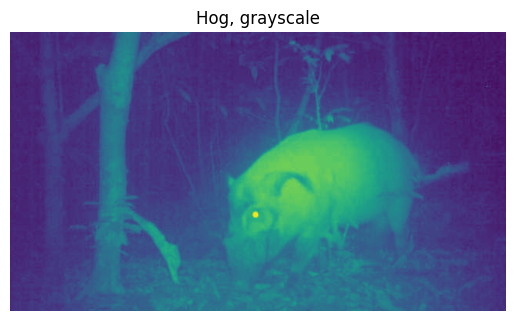

In [91]:
# Create figure with single axis
fig, ax = plt.subplots(1, 1)

# Plot gray channel of hog_tensor
ax.imshow(hog_tensor[0, :, :])

# Turn off x- and y-axis
ax.axis("off")

# Set title
ax.set_title("Hog, grayscale");

While the hog image is grayscale, the antelope image is in color. Its mode is RGB, which stands red, green, and blue. Each of these colors has its own channel in the image. That's where the `3` in the `antelope_tensor` shape `[3, 540, 960]` comes from. We can extract the values for each channel using our slicing skills and plot them side-by-side.

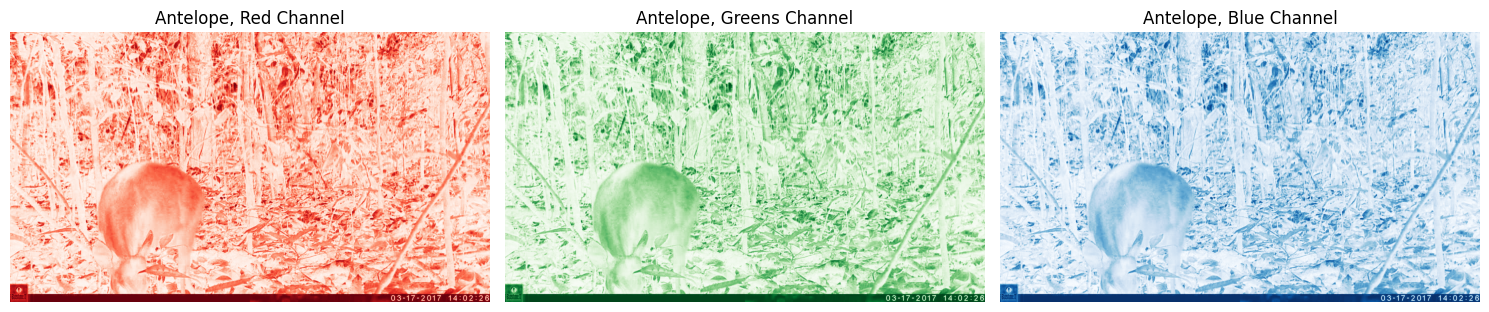

In [92]:
# Create figure with 3 subplots
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(15, 5))

# Plot red channel
red_channel = antelope_tensor[0, :, :]
ax0.imshow(red_channel, cmap="Reds")
ax0.set_title("Antelope, Red Channel")
ax0.axis("off")

# Plot green channel
green_channel = antelope_tensor[1, :, :]
ax1.imshow(red_channel, cmap="Greens")
ax1.set_title("Antelope, Greens Channel")
ax1.axis("off")


# Plot blue channel
blue_channel = antelope_tensor[2, :, :]
ax2.imshow(red_channel, cmap="Blues")
ax2.set_title("Antelope, Blue Channel")
ax2.axis("off")


plt.tight_layout();

The key takeaway is that the dimensions for an image tensor are always **(C x H x W)**, channel by height by width.

We know how the values in an image tensor are organized, but we haven't looked at the values themselves. Focusing on the `antelope_tensor` only, let's check its minimum and maximum values using the `.amax()` and `.amin()` methods.

Now, Let's `Calculate` the minimum and maximum values of `antelope_tensor` and assign the results to `max_channel_values` and `min_channel_values`, respectively.

In [93]:
max_channel_values = antelope_tensor.amax()
min_channel_values = antelope_tensor.amin()

print("max_channel_values class:", type(max_channel_values))
print("max_channel_values shape:", max_channel_values.shape)
print("max_channel_values data type:", max_channel_values.dtype)
print("max_channel_values device:", max_channel_values.device)
print("Max values in antelope_tensor:", max_channel_values)
print()
print("min_channel_values class:", type(min_channel_values))
print("min_channel_values shape:", min_channel_values.shape)
print("min_channel_values data type:", min_channel_values.dtype)
print("min_channel_values device:", min_channel_values.device)
print("Min values in antelope_tensor:", min_channel_values)

max_channel_values class: <class 'torch.Tensor'>
max_channel_values shape: torch.Size([])
max_channel_values data type: torch.float32
max_channel_values device: cpu
Max values in antelope_tensor: tensor(1.)

min_channel_values class: <class 'torch.Tensor'>
min_channel_values shape: torch.Size([])
min_channel_values data type: torch.float32
min_channel_values device: cpu
Min values in antelope_tensor: tensor(0.)


We can see that the values in the tensor range from 0 to 1. 0 means that the color intensity at a particular pixel is 0%; 1 means intensity is 100%.

<div class="alert alert-info" role="alert">
It's equally common to see the values in an image tensor range from 0 to 255. In fact, that's how the values in our image files are actually stored. However, the <code>ToTensor()</code> class <a href="https://pytorch.org/vision/main/generated/torchvision.transforms.ToTensor.html#totensor">automatically converts</a> PIL images from <code>[0, 255]</code> to <code>[0, 1]</code>. So it's always a good idea to double-check image tensor values before building a model. 🤓
</div>

To end this class, we'll do an aggregation calculation to find the mean value for each color channel in `antelope_tensor`. Remember that the color channel is the first dimension in the tensor `(index position `0` in Python)`. This means we want to reduce along the other two dimensions, height and width. They are at index positions `1` and `2`, respectively.

In [94]:
# Calculate the mean values of the separate color channels in antelope_tensor and assign the result to mean_channel_values.
mean_channel_values = antelope_tensor.mean(dim=[1, 2])

print("mean_channel_values class:", type(mean_channel_values))
print("mean_channel_values shape:", mean_channel_values.shape)
print("mean_channel_values dtype:", mean_channel_values.dtype)
print("mean_channel_values device:", mean_channel_values.device)
print("Mean channel values in antelope_tensor (RGB):", mean_channel_values)

mean_channel_values class: <class 'torch.Tensor'>
mean_channel_values shape: torch.Size([3])
mean_channel_values dtype: torch.float32
mean_channel_values device: cpu
Mean channel values in antelope_tensor (RGB): tensor([0.2652, 0.3679, 0.3393])


Think of your image tensor as three separate images stacked together — one for Red, one for Green, and one for Blue. The shape `[3, H, W]` means:

* 3 = the color channels (R, G, B)
* H = height (number of rows of pixels)
* W = width (number of columns of pixels)

When we compute:

```
mean(dim=[1, 2])
```

We are telling PyTorch:

“Take each color channel separately, and compute the average of all its pixels.”

Here’s why `dim=[1, 2]`:

* Dimension 1 = height (rows of pixels)
* Dimension 2 = width (columns of pixels)

So we are averaging across all rows and columns — meaning all the pixels inside each channel.

We are NOT averaging across dimension 0 (the channels), so each channel stays separate.

The result is:

* One average value for Red
* One average value for Green
* One average value for Blue

So the output looks like:

```
[mean_red, mean_green, mean_blue]
```

In simple terms:

We are calculating the average brightness of each color channel independently.


Excellent work! We'll see why it's important to calculate the mean of each color channel in the upcoming classes. For now, here are the key discoveries we've made about our dataset in this lesson:

- Our dataset is organized into folders. We have data for a binary classification model and a multi-class model. In both cases, the training data is divided into subdirectories, one for each class.
- The images in our dataset come in different sizes.
- The images in our dataset come in different modes (grayscale and RGB).
- When we convert our images from PIL to tensors, their values range from `0` to `1`.

In the next class, we'll build tools to combine our images into a uniform dataset of tensors. We'll also build and train a binary classification model using PyTorch.